In [1]:
import torch
print(torch.cuda.is_available())   # should be True
print(torch.version.cuda)          # CUDA version PyTorch is built with
print(torch.cuda.get_device_name(0)) if torch.cuda.is_available() else None
print(torch.cuda.device_count())
import os
os.cpu_count()

True
11.7
NVIDIA RTX 6000 Ada Generation
2


48

In [2]:

from typing import Dict, Tuple, List, Optional
import numpy as np
import pandas as pd
import logging
logger = logging.getLogger(__name__)

def load_ap1_data_from_csv(csv_filepath: str, replicate: Optional[int] = None) -> Dict[str, np.ndarray]:
    """
    Loads AP1 single-cell data from CSV or Excel file.

    Args:
        csv_filepath: Path to the CSV or Excel file

    Returns:
        Dictionary with condition identifiers as keys and feature matrices as values
    """
    logger.info(f"Loading data from: {csv_filepath}")

    # Load the data based on file extension
    if csv_filepath.endswith('.csv'):
        df = pd.read_csv(csv_filepath)
    elif csv_filepath.endswith('.xlsx'):
        df = pd.read_excel(csv_filepath)
    else:
        raise ValueError("Unsupported file format. Please provide a .csv or .xlsx file.")
    
    replacement_map = {
                        '0.316 uM Vemurafenib': 'Vem',
                        '0.316 uM Vem + 0.0316 uM Tram': 'Vem+Tram'
                        }
    df['condition'] = df['condition'].replace(replacement_map)

    print(df['condition'].unique())

    # Define AP1 protein features (these are in log space already)
    ap1_features = [
        'cFOS (log a.u.)', 'p-cFOS (log a.u.)', 'FRA1 (log a.u.)', 'p-FRA1 (log a.u.)', 'FRA2 (log a.u.)',
        'cJUN (log a.u.)', 'p-cJUN (log a.u.)', 'JUNB (log a.u.)', 'JUND (log a.u.)', 'p-ATF1 (log a.u.)',
        'ATF2 (log a.u.)',	 'p-ATF2 (log a.u.)', 'ATF3 (log a.u.)', 'ATF4 (log a.u.)', 'p-ATF4 (log a.u.)',
        'ATF5 (log a.u.)', 'ATF6 (log a.u.)', 'MITF (log a.u.)', 'NGFR (log a.u.)', 'p-ERK (log a.u.)',
    ]

    # Check if all features exist
    missing_features = [f for f in ap1_features if f not in df.columns]
    if missing_features:
        logger.warning(f"Missing features: {missing_features}")
        ap1_features = [f for f in ap1_features if f in df.columns]

    logger.info(f"Using {len(ap1_features)} AP1 features")

    # Create condition-based data dictionary
    data_dict = {}

    if replicate is not None:
        # Group by condition, time, and cell line
        for (condition, time, cell_line, replicate_id), group in df.groupby(['condition', 'time', 'cell_line', 'replicate_id']):
            # Create condition identifier
            condition_id = f"{cell_line}_{condition}_{time.replace(' ', '')}_rep{replicate_id}"

            # Extract feature matrix
            feature_matrix = group[ap1_features].values

            # Remove rows with any NaN values
            valid_rows = ~np.isnan(feature_matrix).any(axis=1)
            feature_matrix = feature_matrix[valid_rows]

            if len(feature_matrix) > 0:
                data_dict[condition_id] = feature_matrix
                logger.info(f"Loaded {condition_id}: {feature_matrix.shape}")
            else:
                logger.warning(f"No valid data for {condition_id}")
    else:
        # Group by condition, time, and cell line
        for (condition, time, cell_line), group in df.groupby(['condition', 'time', 'cell_line']):
            # Create condition identifier
            condition_id = f"{cell_line}_{condition}_{time.replace(' ', '')}"

            # Extract feature matrix
            feature_matrix = group[ap1_features].values

            # Remove rows with any NaN values
            valid_rows = ~np.isnan(feature_matrix).any(axis=1)
            feature_matrix = feature_matrix[valid_rows]

            if len(feature_matrix) > 0:
                data_dict[condition_id] = feature_matrix
                logger.info(f"Loaded {condition_id}: {feature_matrix.shape}")
            else:
                logger.warning(f"No valid data for {condition_id}")

    return data_dict

def prepare_pair_from_mat(cell_line: str,
                          baseline_condition: str, baseline_time: str,
                          target_condition: str, target_time: str,
                          replicate: Optional[int] = None) -> Tuple[np.ndarray, np.ndarray]:
    print("Cell line: ", cell_line)
    raw_data_dict = load_ap1_data_from_csv('mmc5.xlsx', replicate)

    if replicate is not None:
        pre_key = f"{cell_line}_{baseline_condition}_{baseline_time}_rep{replicate}"
        post_key = f"{cell_line}_{target_condition}_{target_time}_rep{replicate}"
    else:
        pre_key = f"{cell_line}_{baseline_condition}_{baseline_time}"
        post_key = f"{cell_line}_{target_condition}_{target_time}"

    if pre_key not in raw_data_dict or post_key not in raw_data_dict:
        raise ValueError(f"Pair not found: {pre_key}, {post_key}")

    # Equalize N
    n = min(len(raw_data_dict[pre_key]), len(raw_data_dict[post_key]))
    X_pre_raw = raw_data_dict[pre_key][:n]
    X_post_raw = raw_data_dict[post_key][:n]
    return X_pre_raw, X_post_raw



In [3]:
import os
import sys
import json
import logging
import argparse
import geomloss
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from tqdm import tqdm
import numpy as np
import pandas as pd
from pathlib import Path
from typing import Dict, Tuple, List, Optional
from umap import UMAP
import matplotlib.pyplot as plt
from scipy.optimize import linear_sum_assignment
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics.pairwise import rbf_kernel
from typing import Dict, Tuple, List
from scipy.stats import ks_2samp
from scipy.spatial.distance import cdist
from sklearn.metrics import r2_score

import gc
gc.collect()

def median_heuristic_gamma(X: np.ndarray, Y: np.ndarray) -> float:
    """
    Median heuristic for RBF bandwidth: gamma = 1 / median(||x - y||^2).
    Uses the median of pairwise distances in the pooled set.
    """
    Z = np.vstack([X, Y])
    # Sample if too large for efficiency
    max_samples = 5000
    if Z.shape[0] > max_samples:
        idx = np.random.choice(Z.shape[0], size=max_samples, replace=False)
        Z = Z[idx]
    D2 = cdist(Z, Z, metric='sqeuclidean')
    # Use upper triangular without diagonal
    triu = D2[np.triu_indices_from(D2, k=1)]
    med = np.median(triu[triu > 0]) if np.any(triu > 0) else 1.0
    return 1.0 / max(med, 1e-12)

def mmd_distance(X: np.ndarray, Y: np.ndarray, gamma: float) -> float:
    """
    Unbiased MMD^2 estimator using Gaussian (RBF) kernel, sklearn backend.

    Args:
        X: (n_samples, n_features) first sample
        Y: (m_samples, n_features) second sample
        gamma: RBF kernel bandwidth; if None, uses median heuristic

    Returns:
        Unbiased MMD^2 value
    """
    n = X.shape[0]
    m = Y.shape[0]

    # Kernel matrices
    Kxx = rbf_kernel(X, X, gamma=gamma)
    Kyy = rbf_kernel(Y, Y, gamma=gamma)
    Kxy = rbf_kernel(X, Y, gamma=gamma)

    # Unbiased: exclude diagonal entries
    np.fill_diagonal(Kxx, 0.0)
    np.fill_diagonal(Kyy, 0.0)

    term_xx = Kxx.sum() / (n * (n - 1)) if n > 1 else 0.0
    term_yy = Kyy.sum() / (m * (m - 1)) if m > 1 else 0.0
    term_xy = 2.0 * Kxy.mean()

    mmd2 = term_xx + term_yy - term_xy
    mmd2 = max(mmd2, 0.0)  # Numerical stability
    return float(mmd2)

def r2_feature_means(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """
    R^2 computed across features between mean vectors of y_true and y_pred.
    """
    mu_true = y_true.mean(axis=0)
    mu_pred = y_pred.mean(axis=0)
    ss_res = float(np.sum((mu_true - mu_pred) ** 2))
    ss_tot = float(np.sum((mu_true - mu_true.mean()) ** 2))
    if ss_tot <= 1e-12:
        return 1.0 if ss_res <= 1e-12 else 0.0
    return 1.0 - ss_res / ss_tot

def wasserstein_pointcloud(
    X,
    Y,
    p: int = 2,
    a=None,
    b=None,
    method: str = "emd",          # "emd" (exact) or "sinkhorn" (approx)
    reg: float = 1e-1,            # Sinkhorn regularization (only used if method="sinkhorn")
    return_plan: bool = False,
):
    """
    Compute Wasserstein distance W_p between two empirical distributions supported on point sets X and Y.

    Parameters
    ----------
    X : (n, d) array-like
        Source points.
    Y : (m, d) array-like
        Target points.
    p : int
        Order of the Wasserstein distance (commonly 1 or 2).
    a : (n,) array-like or None
        Weights for X; if None, uniform weights.
    b : (m,) array-like or None
        Weights for Y; if None, uniform weights.
    method : str
        "emd" for exact optimal transport (requires POT),
        "sinkhorn" for entropic approximation (requires POT).
    reg : float
        Entropic regularization strength for Sinkhorn.
    return_plan : bool
        If True, also return the optimal transport plan.

    Returns
    -------
    Wp : float
        Wasserstein distance of order p.
    plan : (n, m) ndarray, optional
        Optimal transport plan (only if return_plan=True).
    """
    X = np.asarray(X, dtype=np.float64)
    Y = np.asarray(Y, dtype=np.float64)
    if X.ndim != 2 or Y.ndim != 2:
        raise ValueError("X and Y must be 2D arrays with shape (n, d) and (m, d).")
    if X.shape[1] != Y.shape[1]:
        raise ValueError(f"Dimension mismatch: X has d={X.shape[1]}, Y has d={Y.shape[1]}.")

    n, d = X.shape
    m, _ = Y.shape

    if a is None:
        a = np.full(n, 1.0 / n, dtype=np.float64)
    else:
        a = np.asarray(a, dtype=np.float64)
        a = a / a.sum()

    if b is None:
        b = np.full(m, 1.0 / m, dtype=np.float64)
    else:
        b = np.asarray(b, dtype=np.float64)
        b = b / b.sum()

    # Cost matrix: C_ij = ||x_i - y_j||^p
    # Compute squared Euclidean via (x-y)^2 = x^2 + y^2 - 2xy for speed
    X2 = np.sum(X * X, axis=1, keepdims=True)          # (n, 1)
    Y2 = np.sum(Y * Y, axis=1, keepdims=True).T        # (1, m)
    sq = np.maximum(X2 + Y2 - 2.0 * (X @ Y.T), 0.0)     # (n, m)
    if p == 2:
        C = sq
    else:
        C = sq ** (p / 2.0)

    try:
        import ot  # POT: Python Optimal Transport
    except ImportError as e:
        raise ImportError(
            "This function requires the POT library. Install with: pip install pot"
        ) from e

    method = method.lower()
    if method == "emd":
        # exact OT: minimizes <P, C>
        P = ot.emd(a, b, C)
        cost = float(np.sum(P * C))
    elif method == "sinkhorn":
        # entropic OT approximation
        P = ot.sinkhorn(a, b, C, reg=reg)
        cost = float(np.sum(P * C))
    else:
        raise ValueError('method must be either "emd" or "sinkhorn".')

    Wp = cost ** (1.0 / p)

    if return_plan:
        return Wp, P
    return Wp

def summarize_metrics(y_true: np.ndarray, y_pred: np.ndarray, median_gamma: float) -> dict:
    """
    Compute a standard set of metrics: MMD^2 (RBF), R^2 of feature means, median KS across features, and Wasserstein distance.
    """
    # Drop any samples that contain NaNs in either true or pred
    mask = (~np.isnan(y_true).any(axis=1)) & (~np.isnan(y_pred).any(axis=1))
    if mask.sum() < len(y_true):
        print(f"[summarize_metrics] Dropping {len(y_true) - mask.sum()} samples with NaNs.")
    
    y_true = y_true[mask]
    y_pred = y_pred[mask]

    out = {}

    out['mmd2_gamma_median'] = mmd_distance(y_true, y_pred, gamma=median_gamma)
    out['mmd2_gamma_0.5'] = mmd_distance(y_true, y_pred, gamma=0.5)
    out['mmd2_gamma_1.0'] = mmd_distance(y_true, y_pred, gamma=1.0)
    out['wasserstein_distance'] = wasserstein_pointcloud(y_true, y_pred, p=2, method="emd")
    out['R2_feature_means'] = r2_feature_means(y_true, y_pred)
    return out

def split_train_test(X: np.ndarray, Y: np.ndarray, train_fraction: float, seed: int = 42) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    if X.shape[0] != Y.shape[0]:
        min_len = min(len(X), len(Y))
        X = X[:min_len]
        Y = Y[:min_len]

    n = X.shape[0]
    n_train = max(1, int(n * train_fraction))
    rng = np.random.default_rng(seed)
    idx = rng.permutation(n)
    tr_idx, te_idx = idx[:n_train], idx[n_train:]
    return X[tr_idx], X[te_idx], Y[tr_idx], Y[te_idx]

def topk_markers(adata, drug: str, k: int = 50, rank_key: str = "marker_genes-drug-rank"):
    R = adata.varm[rank_key]

    # --- get the rank vector for this drug ---
    if hasattr(R, "columns") and hasattr(R, "iloc"):  # pandas DataFrame
        if drug in R.columns:
            r = R[drug].to_numpy()
        else:
            # fallback: interpret columns as ordered groups; try to map via rank_genes_groups names
            names = adata.uns["rank_genes_groups"]["names"]
            groups = list(names.dtype.names) if (hasattr(names, "dtype") and names.dtype.names is not None) else list(names.columns)
            r = R.iloc[:, groups.index(drug)].to_numpy()
    else:  # numpy array (or array-like)
        names = adata.uns["rank_genes_groups"]["names"]
        groups = list(names.dtype.names) if (hasattr(names, "dtype") and names.dtype.names is not None) else list(names.columns)
        r = np.asarray(R)[:, groups.index(drug)]

    # smaller rank => stronger marker
    idx = np.argsort(r)[:k]
    gene_ids = adata.var_names[idx].to_list()
    gene_short = (adata.var.iloc[idx]["gene_short_name"].to_list()
                  if "gene_short_name" in adata.var.columns else None)
    return gene_ids, gene_short, idx


In [4]:
import sys
import torch
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from cellot.models.cellot import load_networks, compute_loss_f, compute_loss_g

from sklearn.metrics.pairwise import rbf_kernel


def mmd_distance(x, y, gamma):
    xx = rbf_kernel(x, x, gamma)
    xy = rbf_kernel(x, y, gamma)
    yy = rbf_kernel(y, y, gamma)

    return xx.mean() + yy.mean() - 2 * xy.mean()

def compute_mmd_loss(lhs, rhs, gammas):
    return np.mean([mmd_distance(lhs, rhs, g) for g in gammas])

from cellot.losses.mmd import mmd_distance

def run_cellot_pair(train_pre: np.ndarray, train_post: np.ndarray,
                    test_pre: np.ndarray, test_post: np.ndarray,
                    layers: Optional[List[int]] = [64, 64 ,64 ,64],
                    n_epochs: int = 5000,
                    feature_subset: Optional[List[int]] = None,) -> Dict:
    
    device = 'cuda'
    print(f"VERS torch={torch.__version__} (CellOT), device={device}", file=sys.stderr, flush=True)


    # Apply feature subset if specified
    if feature_subset is not None:
        print(f"Using feature subset of size {len(feature_subset)}", file=sys.stderr, flush=True)
        train_pre = train_pre[:, feature_subset]
        train_post = train_post[:, feature_subset]
        test_pre = test_pre[:, feature_subset]
        test_post = test_post[:, feature_subset]

    # Preprocess: standardize jointly and optionally apply PCA for stability
    X_all = np.vstack([train_pre, train_post])
    scaler = StandardScaler()
    X_all_s = scaler.fit_transform(X_all)
    d = X_all_s.shape[1]
    pca_dims = min(50, d)
    if pca_dims < d:
        pca = PCA(n_components=pca_dims, svd_solver='full', random_state=42)
        X_all_p = pca.fit_transform(X_all_s)
        tr_pre_p = X_all_p[:len(train_pre)]
        tr_post_p = X_all_p[len(train_pre):]
        te_pre_p = pca.transform(scaler.transform(test_pre))
        use_pca = True
    else:
        tr_pre_p = X_all_s[:len(train_pre)]
        tr_post_p = X_all_s[len(train_pre):]
        te_pre_p = scaler.transform(test_pre)
        use_pca = False

    # Networks - Using official CellOT configuration
    input_dim = tr_pre_p.shape[1]
    config = {
        'model': {
            'name': 'cellot',
            'hidden_units': layers,
            'kernel_init_fxn': {'name': 'uniform', 'a': -0.01, 'b': 0.01},
            'activation': 'relu',
            'softplus_W_kernels': True,
            'f': {},
            'g': {}
        }
    }
    f, g = load_networks(config, input_dim=input_dim)
    f = f.to(device).float()
    g = g.to(device).float()

    # Data tensors
    src = torch.tensor(tr_pre_p, dtype=torch.float32, device=device)
    tgt = torch.tensor(tr_post_p, dtype=torch.float32, device=device)
    te_src = torch.tensor(te_pre_p, dtype=torch.float32, device=device)

    # Optimizers matching official config
    lr = 1e-4
    optim_f = torch.optim.Adam(f.parameters(), lr=lr, betas=(0.5, 0.9), weight_decay=0)
    optim_g = torch.optim.Adam(g.parameters(), lr=lr, betas=(0.5, 0.9), weight_decay=0)

    # No schedulers in official config
    # n_epochs = 1200  # More epochs for better convergence
    n_epochs = n_epochs + 1  
    # Training loop following official CellOT implementation
    f.train(); g.train()
    batch_size = 256  # Official config
    n_inner_iters = 10  # Official config


    for epoch in range(n_epochs):
        f.train(); g.train()
        perm_t = torch.randperm(len(tgt), device=device)[:batch_size]
        yt = tgt[perm_t]
        
        # Multiple g updates per iteration (official implementation)
        for _ in range(n_inner_iters):
            perm_s = torch.randperm(len(src), device=device)[:batch_size]
            xs = src[perm_s].detach().clone().requires_grad_(True)
            
            optim_g.zero_grad()
            g_loss = compute_loss_g(f, g, xs).mean()
            g_loss.backward()
            torch.nn.utils.clip_grad_norm_(g.parameters(), max_norm=0.5)
            optim_g.step()
        
        # Single f update (official implementation)
        perm_s = torch.randperm(len(src), device=device)[:batch_size]
        xs = src[perm_s].detach().clone().requires_grad_(True)
        
        optim_f.zero_grad()
        f_loss = compute_loss_f(f, g, xs, yt).mean()
        f_loss.backward()
        optim_f.step()
        
        # Clamp weights for f (official implementation)
        if hasattr(f, 'clamp_w'):
            f.clamp_w()
        
        
        # ---- Evaluate train MMD and early-stop ----
        if epoch % 50 == 0: 
            f.eval()
            g.eval()


            # Transport a fixed subset of training PRE (in preprocessed space)
            tr_src_eval = src.requires_grad_(True)
            tr_pred_p = g.transport(tr_src_eval).detach().cpu().numpy()
            # Invert preprocessing to original space (so MMD is comparable to your final eval)
            if use_pca:
                tr_pred = scaler.inverse_transform(pca.inverse_transform(tr_pred_p))
            else:
                tr_pred = scaler.inverse_transform(tr_pred_p)
            train_mmd_min = mmd_distance(train_post, tr_pred, gamma=1.0)


            te_src_full = te_src.detach().clone().requires_grad_(True)
            te_pred_full = g.transport(te_src_full).detach().cpu().numpy()
            if use_pca:
                te_pred_inv_full = scaler.inverse_transform(pca.inverse_transform(te_pred_full))
            else:
                te_pred_inv_full = scaler.inverse_transform(te_pred_full)
            test_metrics = mmd_distance(test_post, te_pred_inv_full, gamma=median_gamma)

            print(
                f"[CellOT] epoch={epoch} f_loss={f_loss.item():.4f} g_loss={g_loss.item():.4f} | "
                f"train mmd={train_mmd_min:.4f} | "
                f"test_mmd={test_metrics:.4f}",
                file=sys.stderr,
                flush=True,
            )

                
            

    # Inference (CellOT transport requires gradients for autodiff)
    f.eval(); g.eval()
    # CellOT needs gradients even in eval mode for transport computation
    te_src_for_transport = te_src.detach().clone().requires_grad_(True)
    te_tx = g.transport(te_src_for_transport).detach().cpu().numpy()

    # Inverse preprocess
    if use_pca:
        te_tx_inv = scaler.inverse_transform(pca.inverse_transform(te_tx))
    else:
        te_tx_inv = scaler.inverse_transform(te_tx)
    # Final evaluation
    metrics = summarize_metrics(test_post[:len(te_tx_inv)], te_tx_inv, median_gamma)

    gammas = np.logspace(1, -3, num=50)
    mmd = compute_mmd_loss(test_post[:len(te_tx_inv)], te_tx_inv, gammas=gammas)
    print(f"[CellOT] Final CellOT MMD: {mmd:.4f}", file=sys.stderr, flush=True)
    
    return {'y_pred': te_tx_inv, 'metrics': metrics}
    


Cell line:  COLO858
['DMSO' 'Vem' 'Vem+Tram']
Cell line:  COLO858
['DMSO' 'Vem' 'Vem+Tram']


VERS torch=1.13.1+cu117 (CellOT), device=cuda


(1371, 20)
(1655, 20)
(1371, 20)
(1655, 20)
Median heuristic gamma: 0.048733884028107605
**************** Run: 0 ****************


[CellOT] epoch=0 f_loss=-3677094.2500 g_loss=4173217.7500 | train mmd=0.1185 | test_mmd=0.8107
[CellOT] epoch=50 f_loss=-100.3197 g_loss=343.7159 | train mmd=0.5145 | test_mmd=0.6096
[CellOT] epoch=100 f_loss=-327.3106 g_loss=398.6413 | train mmd=1.0944 | test_mmd=0.4080
[CellOT] epoch=150 f_loss=-558.2965 g_loss=615.8595 | train mmd=1.0473 | test_mmd=0.3619
[CellOT] epoch=200 f_loss=-644.7821 g_loss=704.8708 | train mmd=0.8213 | test_mmd=0.2995
[CellOT] epoch=250 f_loss=-861.2479 g_loss=955.0323 | train mmd=0.9296 | test_mmd=0.2643
[CellOT] epoch=300 f_loss=-1004.6982 g_loss=1143.6012 | train mmd=0.9112 | test_mmd=0.2276
[CellOT] epoch=350 f_loss=-1154.2510 g_loss=1339.4684 | train mmd=1.0089 | test_mmd=0.2349
[CellOT] epoch=400 f_loss=-1152.5311 g_loss=1249.0269 | train mmd=0.7848 | test_mmd=0.1725
[CellOT] epoch=450 f_loss=-1346.6107 g_loss=1384.5261 | train mmd=0.8936 | test_mmd=0.1778
[CellOT] epoch=500 f_loss=-1508.5465 g_loss=1720.3706 | train mmd=0.9640 | test_mmd=0.1716
[CellO

Run 0 metrics: {'mmd2_gamma_median': 0.08105187313998852, 'mmd2_gamma_0.5': 0.575145644922252, 'mmd2_gamma_1.0': 0.6872777024470895, 'wasserstein_distance': 1.741497467909301, 'R2_feature_means': 0.853614581569434}
**************** Run: 1 ****************


...

[CellOT] epoch=50 f_loss=245.6662 g_loss=238.0458 | train mmd=1.1071 | test_mmd=0.4399
[CellOT] epoch=100 f_loss=-391.3844 g_loss=487.7002 | train mmd=1.1044 | test_mmd=0.4004
[CellOT] epoch=150 f_loss=-645.7002 g_loss=685.3456 | train mmd=0.9263 | test_mmd=0.3231
[CellOT] epoch=200 f_loss=-794.6005 g_loss=905.0718 | train mmd=0.9008 | test_mmd=0.2916
[CellOT] epoch=250 f_loss=-954.6124 g_loss=1026.3502 | train mmd=0.9171 | test_mmd=0.2304
[CellOT] epoch=300 f_loss=-1179.4114 g_loss=1226.3527 | train mmd=1.0025 | test_mmd=0.2393
[CellOT] epoch=350 f_loss=-1323.4556 g_loss=1469.6667 | train mmd=0.9772 | test_mmd=0.2109
[CellOT] epoch=400 f_loss=-1366.5129 g_loss=1605.2544 | train mmd=0.9022 | test_mmd=0.1665
[CellOT] epoch=450 f_loss=-1346.1240 g_loss=1694.0427 | train mmd=0.7830 | test_mmd=0.1258
[CellOT] epoch=500 f_loss=-1068.2063 g_loss=1623.4917 | train mmd=0.4948 | test_mmd=0.0938
[CellOT] epoch=550 f_loss=-1665.9164 g_loss=2087.9343 | train mmd=0.9718 | test_mmd=0.1464
[CellOT] e

Run 8 metrics: {'mmd2_gamma_median': 0.03743563584247167, 'mmd2_gamma_0.5': 0.43201789210206043, 'mmd2_gamma_1.0': 0.6191142970284261, 'wasserstein_distance': 1.8955396363020385, 'R2_feature_means': 0.955476833240327}
**************** Run: 9 ****************


[CellOT] epoch=0 f_loss=-2328122.7500 g_loss=2521260.7500 | train mmd=0.1185 | test_mmd=0.8107
[CellOT] epoch=50 f_loss=188.5659 g_loss=226.3967 | train mmd=1.1066 | test_mmd=0.4374
[CellOT] epoch=100 f_loss=-354.7953 g_loss=447.7141 | train mmd=1.1041 | test_mmd=0.3983
[CellOT] epoch=150 f_loss=-526.5988 g_loss=582.7883 | train mmd=0.8551 | test_mmd=0.2986
[CellOT] epoch=200 f_loss=-719.0788 g_loss=831.2445 | train mmd=0.8794 | test_mmd=0.2801
[CellOT] epoch=250 f_loss=-957.3484 g_loss=1098.7130 | train mmd=1.0129 | test_mmd=0.2682
[CellOT] epoch=300 f_loss=-1185.6322 g_loss=1278.3073 | train mmd=1.0547 | test_mmd=0.2568
[CellOT] epoch=350 f_loss=-1240.6433 g_loss=1455.3107 | train mmd=1.0116 | test_mmd=0.2190
[CellOT] epoch=400 f_loss=-1373.8350 g_loss=1585.3140 | train mmd=1.0112 | test_mmd=0.1979
[CellOT] epoch=450 f_loss=-1418.2158 g_loss=1721.6987 | train mmd=0.9612 | test_mmd=0.1663
[CellOT] epoch=500 f_loss=-1171.8536 g_loss=1361.1953 | train mmd=0.6254 | test_mmd=0.0990
[CellO

Run 9 metrics: {'mmd2_gamma_median': 0.10554215357501562, 'mmd2_gamma_0.5': 0.2675949330089795, 'mmd2_gamma_1.0': 0.2941804843164414, 'wasserstein_distance': 2.0639303756998744, 'R2_feature_means': 0.6488225659006475}
                        mean     std
mmd2_gamma_median     0.1109  0.1068
mmd2_gamma_0.5        0.3582  0.1757
mmd2_gamma_1.0        0.3920  0.1682
wasserstein_distance  2.6776  1.1065
R2_feature_means      0.7696  0.1971


/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_fini

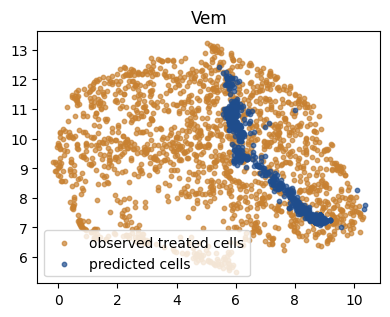

In [5]:
drug = "Vem"
X_pre_replicate_1, X_post_replicate_1 = prepare_pair_from_mat('COLO858', 'DMSO','24h', drug, '72h', 1)
X_pre_replicate_2, X_post_replicate_2 = prepare_pair_from_mat('COLO858', 'DMSO','24h', drug, '72h', 2) 

jfe_indices = [1, 6, 0, 5, 4, 7, 8, 2, 3, 19]  


X_tr_pre = X_pre_replicate_1
Y_tr_post = X_post_replicate_1
X_te_pre = X_pre_replicate_2
Y_te_post = X_post_replicate_2

print(X_tr_pre.shape)
print(X_te_pre.shape)
print(Y_tr_post.shape)
print(Y_te_post.shape)


# Compute median heuristic gamma on training data
median_gamma = median_heuristic_gamma(X_tr_pre, Y_tr_post)
print("Median heuristic gamma:", median_gamma)


all_metrics = []
for run in range(10):
    print(f"**************** Run: {run} ****************")
    seed = 1234 + run
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    out = run_cellot_pair(X_tr_pre[:, jfe_indices], Y_tr_post[:, jfe_indices], X_te_pre[:, jfe_indices], Y_te_post[:, jfe_indices], n_epochs=2000)
    metrics = summarize_metrics(out["y_pred"], Y_te_post[:, jfe_indices], median_gamma)
    print(f"Run {run} metrics: {metrics}")
    all_metrics.append(metrics)

# Results summary
df = pd.DataFrame(all_metrics)
print(df.describe().T[['mean', 'std']].round(4))


from umap import UMAP
import matplotlib.pyplot as plt

source = Y_tr_post[:, jfe_indices]
target = Y_te_post[:, jfe_indices]
predicted = out.get('y_pred') 

# Instantiate UMAP
umap_model = UMAP(n_components=2, random_state=42)

all_sample_umap = umap_model.fit_transform(np.vstack([source, target]))
source_umap = umap_model.transform(source)
target_umap = umap_model.transform(target)
y_pred_umap = umap_model.transform(predicted)

fig, ax = plt.subplots(figsize=(4, 4))
# ax.scatter(source_umap[:, 0], source_umap[:, 1], s=10, alpha=0.7, label='train_post', color='C2')
ax.scatter(target_umap[:, 0], target_umap[:, 1], s=10, alpha=0.7, label='observed treated cells', color="#C88131")
ax.scatter(y_pred_umap[:, 0], y_pred_umap[:, 1], s=10, alpha=0.7, label='predicted cells', color="#1F4D8D")

ax.set_title(f'{drug}')
# ax.set_xlabel('UMAP 1')
# ax.set_ylabel('UMAP 2')
ax.set_aspect('equal', 'box')
# Add a legend to distinguish the points
ax.legend()
# Adjust layout
plt.tight_layout()
# Display the plot
plt.savefig(f"./plots/cellot_on_4i_drug_{drug}.png", dpi=300)

Cell line:  WM902B
['DMSO' 'Vem' 'Vem+Tram']
Cell line:  WM902B
['DMSO' 'Vem' 'Vem+Tram']
(2837, 20)
(2713, 20)
(2837, 20)
(2713, 20)


VERS torch=1.13.1+cu117 (CellOT), device=cuda


Median heuristic gamma: 0.06602327475443821
**************** Run: 0 ****************


[CellOT] epoch=0 f_loss=-3293185.7500 g_loss=4001156.7500 | train mmd=0.1683 | test_mmd=0.7865
[CellOT] epoch=50 f_loss=313.6370 g_loss=298.8002 | train mmd=0.9477 | test_mmd=0.3697
[CellOT] epoch=100 f_loss=-370.8302 g_loss=771.5830 | train mmd=1.0234 | test_mmd=0.3627
[CellOT] epoch=150 f_loss=-598.0834 g_loss=592.2323 | train mmd=1.0381 | test_mmd=0.3329
[CellOT] epoch=200 f_loss=-782.6732 g_loss=828.0439 | train mmd=0.9458 | test_mmd=0.2726
[CellOT] epoch=250 f_loss=-907.7195 g_loss=977.7778 | train mmd=0.8622 | test_mmd=0.2427
[CellOT] epoch=300 f_loss=-1139.2981 g_loss=1166.6775 | train mmd=0.9431 | test_mmd=0.2478
[CellOT] epoch=350 f_loss=-1166.7469 g_loss=1317.4495 | train mmd=0.8211 | test_mmd=0.1946
[CellOT] epoch=400 f_loss=-1434.6980 g_loss=1499.5068 | train mmd=0.8808 | test_mmd=0.1882
[CellOT] epoch=450 f_loss=-1425.5786 g_loss=1625.4021 | train mmd=0.7927 | test_mmd=0.1661
[CellOT] epoch=500 f_loss=-1566.7004 g_loss=2023.5413 | train mmd=0.7285 | test_mmd=0.1324
[CellOT

Run 0 metrics: {'mmd2_gamma_median': 0.11601236330802611, 'mmd2_gamma_0.5': 0.3485404976033265, 'mmd2_gamma_1.0': 0.3353862800875512, 'wasserstein_distance': 1.6419508836165098, 'R2_feature_means': 0.8571270240342516}
**************** Run: 1 ****************


...

[CellOT] epoch=0 f_loss=-3358094.5000 g_loss=3539286.0000 | train mmd=0.1683 | test_mmd=0.7865
[CellOT] epoch=50 f_loss=351.8576 g_loss=224.1146 | train mmd=1.0561 | test_mmd=0.3809
[CellOT] epoch=100 f_loss=-353.0914 g_loss=428.2126 | train mmd=1.0468 | test_mmd=0.3423
[CellOT] epoch=150 f_loss=-604.8691 g_loss=626.7177 | train mmd=0.9649 | test_mmd=0.3173
[CellOT] epoch=200 f_loss=-802.0527 g_loss=860.4946 | train mmd=0.8493 | test_mmd=0.2414
[CellOT] epoch=250 f_loss=-1065.3607 g_loss=1041.3125 | train mmd=0.8853 | test_mmd=0.2263
[CellOT] epoch=300 f_loss=-1133.1050 g_loss=1193.9086 | train mmd=0.8194 | test_mmd=0.1843
[CellOT] epoch=350 f_loss=-1364.1075 g_loss=1482.7513 | train mmd=0.8855 | test_mmd=0.1969
[CellOT] epoch=400 f_loss=-1478.5952 g_loss=1604.6884 | train mmd=0.7849 | test_mmd=0.1460
[CellOT] epoch=450 f_loss=-1535.8420 g_loss=1874.3920 | train mmd=0.7797 | test_mmd=0.1449
[CellOT] epoch=500 f_loss=-1703.7169 g_loss=2005.3879 | train mmd=0.7508 | test_mmd=0.1106
[Cell

Run 8 metrics: {'mmd2_gamma_median': 0.1530287158678496, 'mmd2_gamma_0.5': 0.2207021310253101, 'mmd2_gamma_1.0': 0.20951950880075823, 'wasserstein_distance': 2.4874783719267444, 'R2_feature_means': 0.8419592066936583}
**************** Run: 9 ****************


[CellOT] epoch=0 f_loss=-1865408.3750 g_loss=2224163.0000 | train mmd=0.1683 | test_mmd=0.7865
[CellOT] epoch=50 f_loss=-0.8162 g_loss=226.3992 | train mmd=0.7906 | test_mmd=0.2894
[CellOT] epoch=100 f_loss=-390.4511 g_loss=445.0105 | train mmd=1.0630 | test_mmd=0.3414
[CellOT] epoch=150 f_loss=-604.4287 g_loss=629.8723 | train mmd=0.9297 | test_mmd=0.2859
[CellOT] epoch=200 f_loss=-771.5345 g_loss=881.4531 | train mmd=0.8357 | test_mmd=0.2348
[CellOT] epoch=250 f_loss=-999.7784 g_loss=1020.9460 | train mmd=0.8325 | test_mmd=0.2315
[CellOT] epoch=300 f_loss=-1124.3279 g_loss=1166.4102 | train mmd=0.8084 | test_mmd=0.1902
[CellOT] epoch=350 f_loss=-1596.0208 g_loss=1342.5098 | train mmd=0.7102 | test_mmd=0.1922
[CellOT] epoch=400 f_loss=-1466.4757 g_loss=1455.9624 | train mmd=0.8079 | test_mmd=0.1653
[CellOT] epoch=450 f_loss=-1675.3624 g_loss=1749.9241 | train mmd=0.7859 | test_mmd=0.1349
[CellOT] epoch=500 f_loss=-1605.8865 g_loss=1654.9534 | train mmd=0.7001 | test_mmd=0.1262
[CellOT

Run 9 metrics: {'mmd2_gamma_median': 0.04398130684713708, 'mmd2_gamma_0.5': 0.14540813735829483, 'mmd2_gamma_1.0': 0.24097819849547625, 'wasserstein_distance': 2.0586036429728094, 'R2_feature_means': 0.8823998699543126}
                        mean     std
mmd2_gamma_median     0.0715  0.0480
mmd2_gamma_0.5        0.2036  0.1411
mmd2_gamma_1.0        0.2290  0.1532
wasserstein_distance  1.8707  0.3618
R2_feature_means      0.8957  0.0590


/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_fini

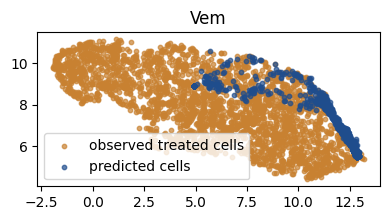

In [6]:

drug = "Vem"
X_pre_replicate_1, X_post_replicate_1 = prepare_pair_from_mat('WM902B', 'DMSO','24h', drug, '72h', 1)
X_pre_replicate_2, X_post_replicate_2 = prepare_pair_from_mat('WM902B', 'DMSO','24h', drug, '72h', 2) 

jfe_indices = [1, 6, 0, 5, 4, 7, 8, 2, 3, 19]  


X_tr_pre = X_pre_replicate_1
Y_tr_post = X_post_replicate_1
X_te_pre = X_pre_replicate_2
Y_te_post = X_post_replicate_2

print(X_tr_pre.shape)
print(X_te_pre.shape)
print(Y_tr_post.shape)
print(Y_te_post.shape)


# Compute median heuristic gamma on training data
median_gamma = median_heuristic_gamma(X_tr_pre, Y_tr_post)
print("Median heuristic gamma:", median_gamma)


all_metrics = []
for run in range(10):
    print(f"**************** Run: {run} ****************")
    seed = 1234 + run
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    out = run_cellot_pair(X_tr_pre[:, jfe_indices], Y_tr_post[:, jfe_indices], X_te_pre[:, jfe_indices], Y_te_post[:, jfe_indices], n_epochs=2000)
    metrics = summarize_metrics(out["y_pred"], Y_te_post[:, jfe_indices], median_gamma)
    print(f"Run {run} metrics: {metrics}")
    all_metrics.append(metrics)

# Results summary
df = pd.DataFrame(all_metrics)
print(df.describe().T[['mean', 'std']].round(4))


from umap import UMAP
import matplotlib.pyplot as plt

source = Y_tr_post[:, jfe_indices]
target = Y_te_post[:, jfe_indices]
predicted = out.get('y_pred') 

# Instantiate UMAP
umap_model = UMAP(n_components=2, random_state=42)

all_sample_umap = umap_model.fit_transform(np.vstack([source, target]))
source_umap = umap_model.transform(source)
target_umap = umap_model.transform(target)
y_pred_umap = umap_model.transform(predicted)

fig, ax = plt.subplots(figsize=(4, 4))
# ax.scatter(source_umap[:, 0], source_umap[:, 1], s=10, alpha=0.7, label='train_post', color='C2')
ax.scatter(target_umap[:, 0], target_umap[:, 1], s=10, alpha=0.7, label='observed treated cells', color="#C88131")
ax.scatter(y_pred_umap[:, 0], y_pred_umap[:, 1], s=10, alpha=0.7, label='predicted cells', color="#1F4D8D")

ax.set_title(f'{drug}')
# ax.set_xlabel('UMAP 1')
# ax.set_ylabel('UMAP 2')
ax.set_aspect('equal', 'box')
# Add a legend to distinguish the points
ax.legend()
# Adjust layout
plt.tight_layout()
# Display the plot
plt.savefig(f"./plots/cellot_on_4i_drug_{drug}.png", dpi=300)

Cell line:  SKMEL19
['DMSO' 'Vem' 'Vem+Tram']
Cell line:  SKMEL19


['DMSO' 'Vem' 'Vem+Tram']


VERS torch=1.13.1+cu117 (CellOT), device=cuda


(1514, 20)
(1163, 20)
(1514, 20)
(1163, 20)
Median heuristic gamma: 0.10646172143931386
**************** Run: 0 ****************


[CellOT] epoch=0 f_loss=-4923884.0000 g_loss=5386631.0000 | train mmd=0.1295 | test_mmd=0.6883
[CellOT] epoch=50 f_loss=-168.3289 g_loss=940.6224 | train mmd=0.5316 | test_mmd=0.3072
[CellOT] epoch=100 f_loss=-73.6705 g_loss=326.1705 | train mmd=0.6572 | test_mmd=0.2033
[CellOT] epoch=150 f_loss=-372.9241 g_loss=437.9910 | train mmd=0.6086 | test_mmd=0.1466
[CellOT] epoch=200 f_loss=-599.6742 g_loss=567.1274 | train mmd=0.2689 | test_mmd=0.0837
[CellOT] epoch=250 f_loss=-723.5936 g_loss=473.9569 | train mmd=0.4473 | test_mmd=0.0838
[CellOT] epoch=300 f_loss=-1102.1606 g_loss=640.4041 | train mmd=0.2867 | test_mmd=0.1215
[CellOT] epoch=350 f_loss=-1228.4021 g_loss=873.5383 | train mmd=0.3451 | test_mmd=0.1233
[CellOT] epoch=400 f_loss=-652.1746 g_loss=1961.1274 | train mmd=0.4663 | test_mmd=0.0761
[CellOT] epoch=450 f_loss=-4573.9072 g_loss=943.4496 | train mmd=0.6036 | test_mmd=0.4685
[CellOT] epoch=500 f_loss=-3478.1860 g_loss=1000.4998 | train mmd=0.2514 | test_mmd=0.1059
[CellOT] ep

...

[CellOT] epoch=50 f_loss=474.4604 g_loss=664.7349 | train mmd=0.7189 | test_mmd=0.2255
[CellOT] epoch=100 f_loss=-22.6244 g_loss=343.7224 | train mmd=0.6713 | test_mmd=0.1861
[CellOT] epoch=150 f_loss=-440.1357 g_loss=469.0575 | train mmd=0.7077 | test_mmd=0.2000
[CellOT] epoch=200 f_loss=-491.7725 g_loss=866.3317 | train mmd=0.4298 | test_mmd=0.0836
[CellOT] epoch=250 f_loss=-644.7627 g_loss=754.4441 | train mmd=0.5763 | test_mmd=0.1069
[CellOT] epoch=300 f_loss=-845.6731 g_loss=617.6860 | train mmd=0.4561 | test_mmd=0.0757
[CellOT] epoch=350 f_loss=-860.4346 g_loss=1044.5000 | train mmd=0.4839 | test_mmd=0.0724
[CellOT] epoch=400 f_loss=-892.9375 g_loss=1093.3972 | train mmd=0.5443 | test_mmd=0.0880
[CellOT] epoch=450 f_loss=-843.1953 g_loss=1214.5449 | train mmd=0.4359 | test_mmd=0.0506
[CellOT] epoch=500 f_loss=-1347.3142 g_loss=1935.1488 | train mmd=0.3983 | test_mmd=0.0501
[CellOT] epoch=550 f_loss=-929.3497 g_loss=1347.8683 | train mmd=0.4576 | test_mmd=0.0707
[CellOT] epoch=600

Run 8 metrics: {'mmd2_gamma_median': 0.038348169625573636, 'mmd2_gamma_0.5': 0.10283484145161503, 'mmd2_gamma_1.0': 0.17771617590346883, 'wasserstein_distance': 1.1960697893490078, 'R2_feature_means': 0.9136074568339576}
**************** Run: 9 ****************


[CellOT] epoch=50 f_loss=-650.6722 g_loss=421.4122 | train mmd=0.4885 | test_mmd=0.3795
[CellOT] epoch=100 f_loss=-84.0149 g_loss=273.1636 | train mmd=0.7210 | test_mmd=0.1977
[CellOT] epoch=150 f_loss=-348.8495 g_loss=397.1488 | train mmd=0.6400 | test_mmd=0.1493
[CellOT] epoch=200 f_loss=-514.2339 g_loss=550.8160 | train mmd=0.5972 | test_mmd=0.1193
[CellOT] epoch=250 f_loss=-989.4354 g_loss=696.6660 | train mmd=0.4339 | test_mmd=0.1520
[CellOT] epoch=300 f_loss=-664.2625 g_loss=1526.2148 | train mmd=0.5074 | test_mmd=0.1448
[CellOT] epoch=350 f_loss=-791.8000 g_loss=861.7194 | train mmd=0.3741 | test_mmd=0.0933
[CellOT] epoch=400 f_loss=-799.9877 g_loss=1541.0670 | train mmd=0.5061 | test_mmd=0.0827
[CellOT] epoch=450 f_loss=-770.0315 g_loss=686.3711 | train mmd=0.2587 | test_mmd=0.0708
[CellOT] epoch=500 f_loss=-789.8694 g_loss=1680.9099 | train mmd=0.3728 | test_mmd=0.0597
[CellOT] epoch=550 f_loss=-1599.5956 g_loss=6116.4751 | train mmd=0.4875 | test_mmd=0.2392
[CellOT] epoch=600

Run 9 metrics: {'mmd2_gamma_median': 0.08040033179466821, 'mmd2_gamma_0.5': 0.19018335729589697, 'mmd2_gamma_1.0': 0.212673467841908, 'wasserstein_distance': 1.3089367733437118, 'R2_feature_means': 0.9300680004783706}
                        mean     std
mmd2_gamma_median     0.0849  0.0697
mmd2_gamma_0.5        0.1868  0.1043
mmd2_gamma_1.0        0.2331  0.0661
wasserstein_distance  1.3650  0.1568
R2_feature_means      0.8527  0.1063


/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


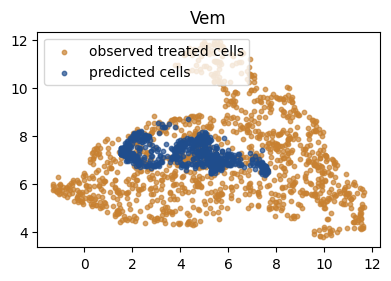

In [7]:
drug = "Vem"
X_pre_replicate_1, X_post_replicate_1 = prepare_pair_from_mat('SKMEL19', 'DMSO','24h', drug, '72h', 1)
X_pre_replicate_2, X_post_replicate_2 = prepare_pair_from_mat('SKMEL19', 'DMSO','24h', drug, '72h', 2) 

jfe_indices = [1, 6, 0, 5, 4, 7, 8, 2, 3, 19]  


X_tr_pre = X_pre_replicate_1
Y_tr_post = X_post_replicate_1
X_te_pre = X_pre_replicate_2
Y_te_post = X_post_replicate_2

print(X_tr_pre.shape)
print(X_te_pre.shape)
print(Y_tr_post.shape)
print(Y_te_post.shape)

# Compute median heuristic gamma on training data
median_gamma = median_heuristic_gamma(X_tr_pre, Y_tr_post)
print("Median heuristic gamma:", median_gamma)


all_metrics = []
for run in range(10):
    print(f"**************** Run: {run} ****************")
    seed = 1234 + run
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    out = run_cellot_pair(X_tr_pre[:, jfe_indices], Y_tr_post[:, jfe_indices], X_te_pre[:, jfe_indices], Y_te_post[:, jfe_indices], n_epochs=2000)
    metrics = summarize_metrics(out["y_pred"], Y_te_post[:, jfe_indices], median_gamma)
    print(f"Run {run} metrics: {metrics}")
    all_metrics.append(metrics)

# Results summary
df = pd.DataFrame(all_metrics)
print(df.describe().T[['mean', 'std']].round(4))


from umap import UMAP
import matplotlib.pyplot as plt

source = Y_tr_post[:, jfe_indices]
target = Y_te_post[:, jfe_indices]
predicted = out.get('y_pred') 

# Instantiate UMAP
umap_model = UMAP(n_components=2, random_state=42)

all_sample_umap = umap_model.fit_transform(np.vstack([source, target]))
source_umap = umap_model.transform(source)
target_umap = umap_model.transform(target)
y_pred_umap = umap_model.transform(predicted)

fig, ax = plt.subplots(figsize=(4, 4))
# ax.scatter(source_umap[:, 0], source_umap[:, 1], s=10, alpha=0.7, label='train_post', color='C2')
ax.scatter(target_umap[:, 0], target_umap[:, 1], s=10, alpha=0.7, label='observed treated cells', color="#C88131")
ax.scatter(y_pred_umap[:, 0], y_pred_umap[:, 1], s=10, alpha=0.7, label='predicted cells', color="#1F4D8D")

ax.set_title(f'{drug}')
# ax.set_xlabel('UMAP 1')
# ax.set_ylabel('UMAP 2')
ax.set_aspect('equal', 'box')
# Add a legend to distinguish the points
ax.legend()
# Adjust layout
plt.tight_layout()
# Display the plot
plt.savefig(f"./plots/cellot_on_4i_drug_{drug}.png", dpi=300)